links:
- https://www.geeksforgeeks.org/python/python-loop-through-folders-and-files-in-directory/

notes:
- to handle class imbalance (750/250) tell the loss function to care more about the minority class.
-

## Import packages
---


In [28]:
import pandas as pd
import os
import cv2
import numpy as np
import tensorflow as tf
from keras.src.layers import Rescaling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

### Load real images
---


In [29]:
dir = "data/real_dataset/"

valid_extensions = (".jpg", ".jpeg", ".png")

# collect all sub-folder paths
sub_folder_paths = []

for root, dirs, files in os.walk(dir):
    for filename in files:
        if filename.lower().endswith(valid_extensions):
            sub_folder_paths.append(os.path.join(root, filename)) # append full path

images_real = [] # numpy Array (from cv2)
for path in sub_folder_paths:
    img = cv2.imread(path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images_real.append(img)

print(f'loaded {len(images_real)} images')


loaded 745 images


### Load Ai generated images
---


In [30]:
dir = "data/ai_generated_dataset/"

valid_extensions = (".jpg", ".jpeg", ".png")

# collect all sub-folder paths
sub_folder_paths = []

for root, dirs, files in os.walk(dir):
    for filename in files:
        if filename.lower().endswith(valid_extensions):
            sub_folder_paths.append(os.path.join(root, filename)) # append full path

images_ai = []
for path in sub_folder_paths:
    img = cv2.imread(path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images_ai.append(img)

print(f'loaded {len(images_ai)} images')

loaded 250 images


### Data Augmentation
---
TODO: Mirroring, Noise, Blur, Rotation

### Set weights to handle class imbalance
---


In [31]:
num_pictures =  len(images_real) + len(images_ai)

weights_real = num_pictures / (2 * len(images_real))
weights_ai = num_pictures / (2 * len(images_ai))

# create a dictionary with class weights
# 0 = real
# 1 = ai generated
class_weights = {
    0: weights_real,
    1: weights_ai
}

print(f'weights: {class_weights}')

weights: {0: 0.6677852348993288, 1: 1.99}


# Standardize Image Sizes
----


In [32]:
IMG_SIZE = (224,224)

processed_real = [cv2.resize(img, IMG_SIZE) for img in images_real]
processed_ai = [cv2.resize(img, IMG_SIZE) for img in images_ai]

X_real = np.array(processed_real)
X_ai = np.array(processed_ai)

y_real = np.zeros(len(X_real), dtype=np.int32)  # class 0
y_ai = np.ones(len(X_ai), dtype=np.int32)       # class 1

X_combined = np.concatenate([X_real, X_ai], axis=0)
y_combined = np.concatenate([y_real, y_ai], axis=0)

# Build Tensorflow dataset
---


In [33]:
ds = tf.data.Dataset.from_tensor_slices((X_combined,y_combined))

BUFFER_SIZE = len(X_combined)
SPLIT = 0.8
BATCH_SIZE = 32

ds = ds.shuffle(buffer_size=BUFFER_SIZE)

train_ds = ds.take(int(SPLIT * BUFFER_SIZE))
val_ds = ds.skip(int(SPLIT * BUFFER_SIZE))

train_ds = train_ds.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)


# Build Tensorflow CNN
---


In [35]:

model = Sequential([
    #Rescaling(1./255, input_shape=(224,224,3)), # Scale to values between 0 and 1

    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),

    Dense(1, activation='sigmoid') # 0 = real, 1 = ai generated
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5352 - loss: 165.8161 - val_accuracy: 0.8492 - val_loss: 0.4069
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 620ms/step - accuracy: 0.8241 - loss: 0.4388 - val_accuracy: 0.8794 - val_loss: 0.3336
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 449ms/step - accuracy: 0.9183 - loss: 0.2758 - val_accuracy: 0.9196 - val_loss: 0.2013
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 415ms/step - accuracy: 0.9259 - loss: 0.2273 - val_accuracy: 0.9497 - val_loss: 0.1305
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 455ms/step - accuracy: 0.9196 - loss: 0.3186 - val_accuracy: 0.9598 - val_loss: 0.1690
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 473ms/step - accuracy: 0.9548 - loss: 0.1626 - val_accuracy: 0.9950 - val_loss: 0.0549
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 460ms/step - accuracy: 0.9824 - loss: 0.0929 - val_accuracy: 0.9799 - val_loss: 0.0900
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 507ms/step - accuracy: 0.9925 - loss: 0.0652 - val_accur

# Test Data with val_ds
---

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step
              precision    recall  f1-score   support

    Real (0)       0.73      0.68      0.71       149
      AI (1)       0.20      0.24      0.22        50

    accuracy                           0.57       199
   macro avg       0.47      0.46      0.46       199
weighted avg       0.60      0.57      0.58       199



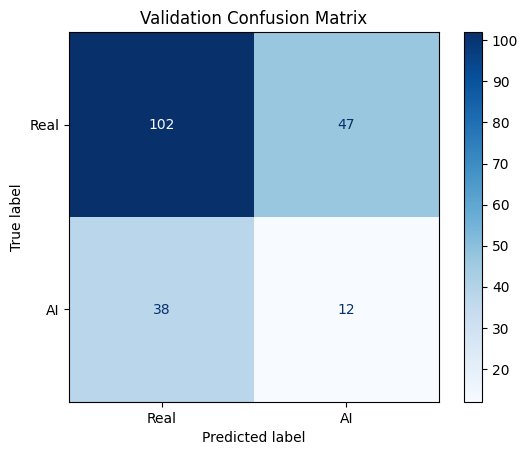

In [36]:
import numpy as np

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_pred_probs = model.predict(val_ds)

# 3. Convert probabilities to binary choices (0 or 1)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

from sklearn.metrics import classification_report

# Print precision, recall, and F1-score
print(classification_report(y_true, y_pred, target_names=['Real (0)', 'AI (1)']))

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'AI'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Validation Confusion Matrix")
plt.show()

# Save model to disk
---


In [ ]:
# save model to disk
